<xarray.Dataset>
Dimensions:    (time: 2, latitude: 4320, longitude: 8640)
Coordinates:
  * latitude   (latitude) float32 -89.98 -89.94 -89.9 ... 89.9 89.94 89.98
  * longitude  (longitude) float32 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time       (time) datetime64[ns] 1998-01-01 1998-02-01
Data variables:
    PP         (time, latitude, longitude) float32 ...
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L4_MY_009_104
    ...                              ...
    time_coverage_resolution:        P28D
    time_coverage_start:             2026-01-31T18:24:51Z
    title:                           cmems_obs-oc_glo_bgc-pp_my_l4-multi-4km_

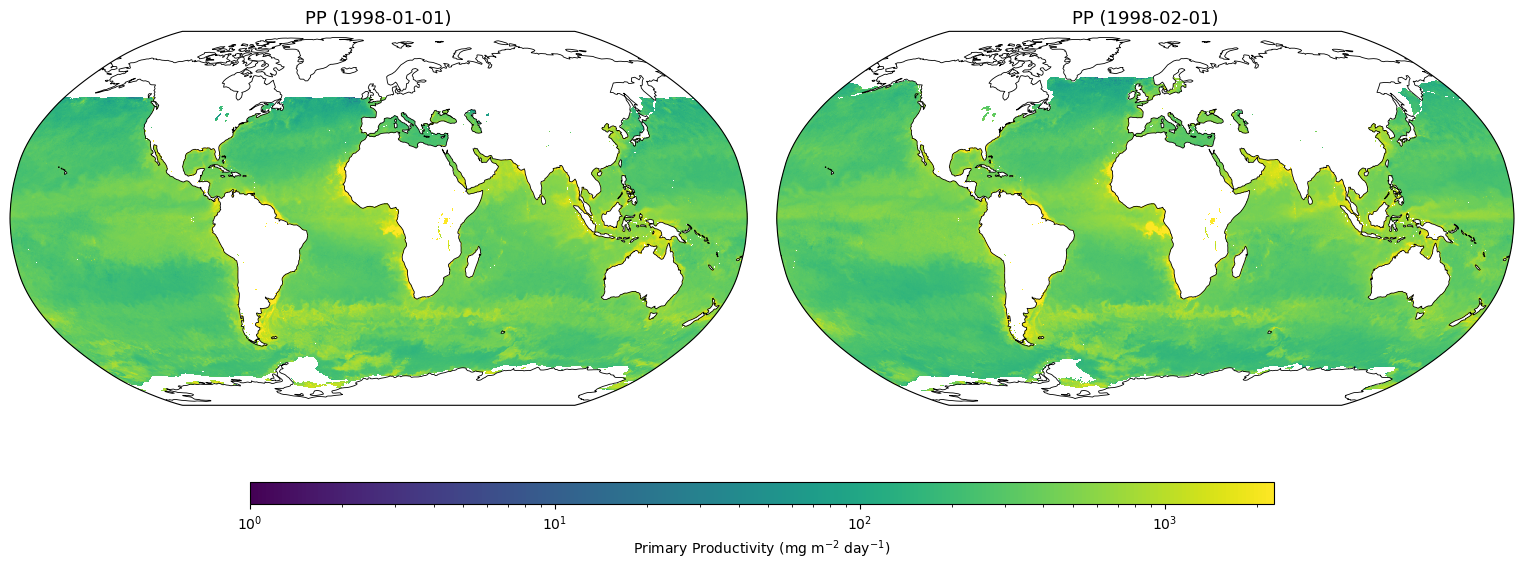

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs


# ============================================================
# File
# ============================================================

FILE = "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_01.nc"

ds = xr.open_dataset(FILE, decode_times=True)
print(ds)
print(ds.time.values)


# ============================================================
# Basic preprocessing
# ============================================================

pp = ds["PP"]

# mask fill value and invalid values
fill_value = pp.attrs.get("_FillValue", -999.0)
pp = pp.where(pp != fill_value)
pp = pp.where(pp >= 0)

# quick-look용 다운샘플
# 너무 느리면 8, 12로 키우고
# 원해상도로 보려면 stride = 1
stride = 4

pp_plot = pp.isel(
    latitude=slice(None, None, stride),
    longitude=slice(None, None, stride)
)

lon = ds["longitude"].isel(longitude=slice(None, None, stride)).values
lat = ds["latitude"].isel(latitude=slice(None, None, stride)).values

# color scale: 두 time slice에 공통으로 적용
# PP는 분포가 치우쳐 있으니 log scale이 보기 편함
vmin = 1.0
vmax = float(np.nanpercentile(pp_plot.values, 99.5))
if vmax <= vmin:
    vmax = 1000.0


# ============================================================
# Plot: both time slices
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6.2),
    subplot_kw={"projection": ccrs.Robinson()}
)

for i, ax in enumerate(axes):
    data = pp_plot.isel(time=i)

    im = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )

    ax.coastlines(linewidth=0.6)
    ax.set_global()

    tval = pd.to_datetime(ds.time.values[i])
    ax.set_title(f"PP ({tval.strftime('%Y-%m-%d')})", fontsize=13)

# Make enough room at the bottom
fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.18,
    wspace=0.04,
)

# Dedicated colorbar axis: [left, bottom, width, height]
cax = fig.add_axes([0.18, 0.08, 0.64, 0.035])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
)

cbar.set_label("Primary Productivity (mg m$^{-2}$ day$^{-1}$)")

plt.show()

Number of files: 12
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_01.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_02.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_03.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_04.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_05.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_06.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_07.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_08.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_09.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_10.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_11.nc
/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_12.nc
vmin: 1.0
vmax: 2636.1959777832335


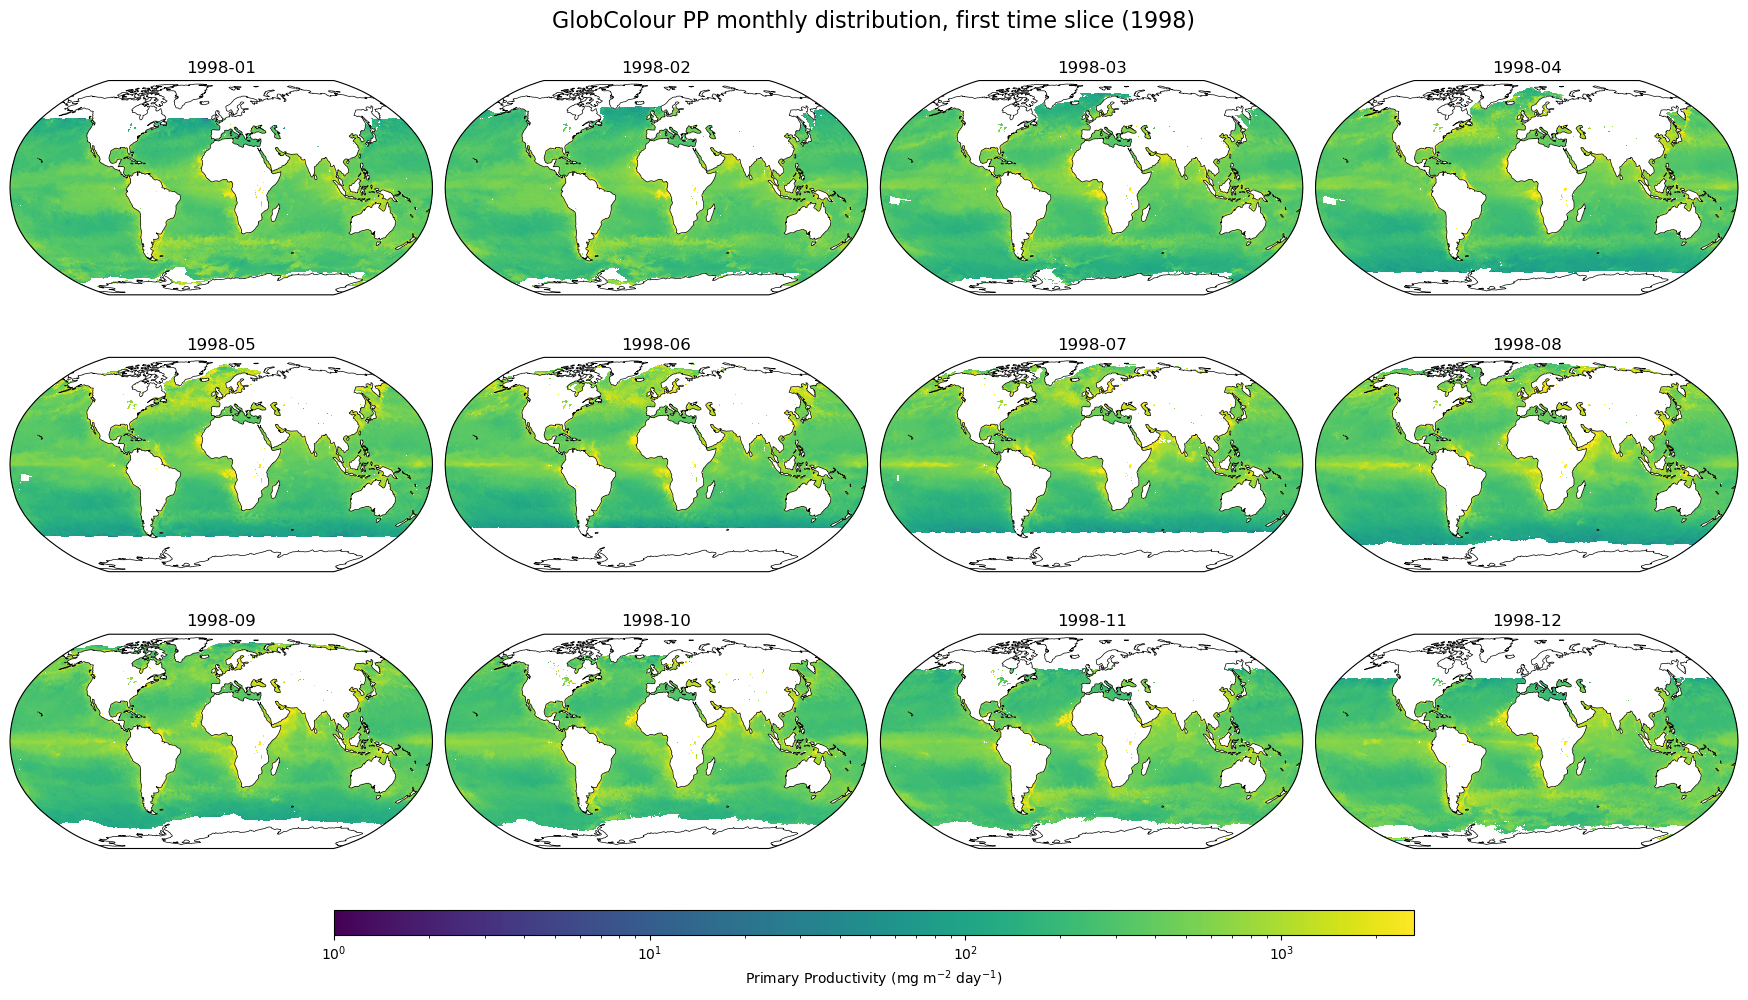

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
from pathlib import Path
import glob


# ============================================================
# Settings
# ============================================================

DATA_DIR = Path("/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour")
YEAR = 1998

files = sorted(glob.glob(str(DATA_DIR / f"PP_{YEAR}_*.nc")))

print("Number of files:", len(files))
for f in files:
    print(f)

# quick-look downsampling
# 너무 느리면 8 또는 12
# 더 고해상도로 보고 싶으면 2 또는 1
stride = 4


# ============================================================
# Read first time slice from each monthly file
# ============================================================

pp_list = []
time_list = []

for f in files:
    ds = xr.open_dataset(f, decode_times=True)

    pp = ds["PP"].isel(time=0)

    # Mask fill value and invalid values
    fill_value = pp.attrs.get("_FillValue", -999.0)
    pp = pp.where(pp != fill_value)
    pp = pp.where(pp > 0)   # LogNorm을 위해 0도 제거

    # Downsample for quick plotting
    pp = pp.isel(
        latitude=slice(None, None, stride),
        longitude=slice(None, None, stride),
    )

    pp_list.append(pp)

    # title용 time 저장
    try:
        time_list.append(pd.to_datetime(ds["time"].isel(time=0).values))
    except Exception:
        time_list.append(None)

    ds.close()

# Use lon/lat from the first file
ds0 = xr.open_dataset(files[0], decode_times=True)

lon = ds0["longitude"].isel(longitude=slice(None, None, stride)).values
lat = ds0["latitude"].isel(latitude=slice(None, None, stride)).values

ds0.close()


# ============================================================
# Common color scale
# ============================================================

# 12개월 전체를 같은 colorbar로 비교
all_values = np.concatenate([
    pp.values.ravel()
    for pp in pp_list
])

all_values = all_values[np.isfinite(all_values)]
all_values = all_values[all_values > 0]

vmin = 1.0
vmax = float(np.nanpercentile(all_values, 99.5))

if vmax <= vmin:
    vmax = 1000.0

print("vmin:", vmin)
print("vmax:", vmax)


# ============================================================
# Plot 12 monthly panels
# ============================================================

fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 10),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.ravel()

for i, ax in enumerate(axes):
    data = pp_list[i]

    im = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )

    ax.coastlines(linewidth=0.5)
    ax.set_global()

    if time_list[i] is not None:
        title = time_list[i].strftime("%Y-%m")
    else:
        title = Path(files[i]).stem.replace("PP_", "")

    ax.set_title(title, fontsize=12)

# Layout
fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.93,
    bottom=0.12,
    wspace=0.03,
    hspace=0.08,
)

# Dedicated colorbar axis
cax = fig.add_axes([0.20, 0.055, 0.60, 0.025])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
)

cbar.set_label("Primary Productivity (mg m$^{-2}$ day$^{-1}$)")

fig.suptitle(
    f"GlobColour PP monthly distribution, first time slice ({YEAR})",
    fontsize=16
)

plt.show()

In [6]:
import re
import glob
from pathlib import Path
from datetime import date

import numpy as np
import xarray as xr
import pandas as pd


# ============================================================
# Settings
# ============================================================

DATA_DIR = Path("/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour")

# 네가 방금 만든 conservative 13-region mask file
REGION_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/RECCAP2/"
    "RECCAP2_region_mask_13regions_conservative_v20260707.nc"
)

REGION_VAR = "region_mask"

YEAR_START = 1998
YEAR_END   = 2025

OUT_DIR = DATA_DIR / "RECCAP2_region_mean_PP"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / f"GlobColour_PP_RECCAP2_13regions_area_mean_{YEAR_START}_{YEAR_END}.nc"

VERBOSE_ZERO_FILL = False   # True로 하면 region별 zero-fill 로그를 화면 출력
PROGRESS_EVERY = 12         # 12개월마다 한 번만 progress 출력

# ============================================================
# Helper functions
# ============================================================

def parse_pp_filename(path):
    """
    Parse filename like PP_1998_01.nc.
    """
    name = Path(path).name
    m = re.match(r"PP_(\d{4})_(\d{2})\.nc$", name)
    if m is None:
        return None

    year = int(m.group(1))
    month = int(m.group(2))

    return year, month


def parse_region_name_attr(attr):
    """
    Parse attribute like:
    '1.NA STSS, 2.NA STPS, ...'
    """
    out = {}

    if attr is None:
        return out

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        code, name = item.split(".", 1)
        try:
            out[int(code.strip())] = name.strip()
        except ValueError:
            pass

    return out


def parse_region_source_attr(attr):
    """
    Parse attribute like:
    '1.atlantic:2.NA STSS, 2.atlantic:3.NA STPS, ...'
    """
    rows = []

    if attr is None:
        return pd.DataFrame(columns=["region", "basin", "original_region_id", "region_name"])

    for item in attr.split(","):
        item = item.strip()
        if "." not in item:
            continue

        code_str, rest = item.split(".", 1)

        try:
            code = int(code_str.strip())
        except ValueError:
            continue

        if ":" in rest:
            basin, rest2 = rest.split(":", 1)
            basin = basin.strip()

            if "." in rest2:
                original_id_str, name = rest2.split(".", 1)
                try:
                    original_id = int(original_id_str.strip())
                except ValueError:
                    original_id = -999

                name = name.strip()
            else:
                original_id = -999
                name = rest2.strip()
        else:
            basin = ""
            original_id = -999
            name = rest.strip()

        rows.append(
            {
                "region": code,
                "basin": basin,
                "original_region_id": original_id,
                "region_name": name,
            }
        )

    return pd.DataFrame(rows).sort_values("region").reset_index(drop=True)


def build_highres_region_mask(region_mask, pp_lat, pp_lon):
    """
    Put 1-degree RECCAP2 region_mask onto GlobColour PP grid.

    This uses nearest 1-degree cell assignment.
    Longitude is treated cyclically in 0-360 convention.
    """
    # Ensure source mask uses increasing latitude and 0-360 longitude
    rm = region_mask.copy()

    rm = rm.assign_coords(lon=((rm["lon"] + 360.0) % 360.0))
    rm = rm.sortby("lon")
    rm = rm.sortby("lat")

    mask_lat = rm["lat"].values
    mask_lon = rm["lon"].values
    mask_np = rm.values.astype(np.int16)

    # Infer regular grid spacing
    dlat = float(np.nanmedian(np.diff(mask_lat)))
    dlon = float(np.nanmedian(np.diff(mask_lon)))

    lat0 = float(mask_lat[0])
    lon0 = float(mask_lon[0])

    # Nearest source latitude index
    lat_idx = np.rint((pp_lat - lat0) / dlat).astype(int)
    lat_idx = np.clip(lat_idx, 0, len(mask_lat) - 1)

    # Nearest source longitude index, cyclic
    pp_lon360 = (pp_lon + 360.0) % 360.0
    lon_idx = np.rint((pp_lon360 - lon0) / dlon).astype(int) % len(mask_lon)

    # Broadcast to 2D target grid
    highres_mask = mask_np[lat_idx[:, None], lon_idx[None, :]]

    return highres_mask.astype(np.int16)


# ============================================================
# Find PP files
# ============================================================

all_files = sorted(glob.glob(str(DATA_DIR / "PP_*.nc")))

records = []
for f in all_files:
    parsed = parse_pp_filename(f)

    if parsed is None:
        continue

    year, month = parsed

    if YEAR_START <= year <= YEAR_END:
        records.append(
            {
                "file": f,
                "year": year,
                "month": month,
                # Monthly representative time.
                # We use filename-based time because some GlobColour metadata can be confusing.
                "time": np.datetime64(f"{year:04d}-{month:02d}-15"),
            }
        )

records = sorted(records, key=lambda x: (x["year"], x["month"]))

print(f"Number of PP files found: {len(records)}")

expected_n = (YEAR_END - YEAR_START + 1) * 12
if len(records) != expected_n:
    print(f"WARNING: expected {expected_n} files, but found {len(records)}")

for r in records[:3]:
    print("first files:", r["file"])
for r in records[-3:]:
    print("last files :", r["file"])


# ============================================================
# Read region mask metadata
# ============================================================

mask_ds = xr.open_dataset(REGION_MASK_FILE)
region_mask = mask_ds[REGION_VAR]

region_names = parse_region_name_attr(region_mask.attrs.get("region_name"))
region_table = parse_region_source_attr(region_mask.attrs.get("region_source"))

region_codes = np.array(sorted([int(v) for v in np.unique(region_mask.values) if v > 0]), dtype=np.int16)
n_region = len(region_codes)

print("\nRegion codes:", region_codes)
print(f"Number of regions: {n_region}")

if len(region_table) == 0:
    region_table = pd.DataFrame(
        {
            "region": region_codes,
            "basin": [""] * n_region,
            "original_region_id": [-999] * n_region,
            "region_name": [region_names.get(int(c), f"region {int(c)}") for c in region_codes],
        }
    )

print("\nRegion table:")
print(region_table.to_string(index=False))


# ============================================================
# Build high-resolution region mask on PP grid
# ============================================================

# Use first PP file to get GlobColour grid
with xr.open_dataset(records[0]["file"], decode_times=False, mask_and_scale=False) as ds0:
    pp_lat = ds0["latitude"].values.astype(np.float64)
    pp_lon = ds0["longitude"].values.astype(np.float64)

print("\nPP grid:")
print("lat:", pp_lat.shape, pp_lat.min(), pp_lat.max())
print("lon:", pp_lon.shape, pp_lon.min(), pp_lon.max())

print("\nBuilding high-resolution region mask on PP grid...")
region_on_pp = build_highres_region_mask(region_mask, pp_lat, pp_lon)

# Flattened arrays for fast regional aggregation
region_flat = region_on_pp.ravel()
selected_flat = region_flat > 0

# Latitude area weight for regular lon-lat grid
lat_weight = np.cos(np.deg2rad(pp_lat)).astype(np.float64)

# Repeat latitude weights across longitude
# This is proportional to grid-cell area because dlat and dlon are constant.
nlat = len(pp_lat)
nlon = len(pp_lon)
weight_flat = np.repeat(lat_weight, nlon)

# Total selected area weight per region, independent of PP missing data
max_code = int(region_codes.max())
region_total_weight = np.bincount(
    region_flat[selected_flat],
    weights=weight_flat[selected_flat],
    minlength=max_code + 1,
)

print("Done building region mask.")


# ============================================================
# Loop over monthly PP files
# ============================================================

n_time = len(records)

pp_mean = np.full((n_time, n_region), np.nan, dtype=np.float32)

# Diagnostics
negative_grid_count = np.zeros((n_time, n_region), dtype=np.int32)
nan_grid_count = np.zeros((n_time, n_region), dtype=np.int32)
zero_filled_grid_count = np.zeros((n_time, n_region), dtype=np.int32)

negative_area_fraction = np.zeros((n_time, n_region), dtype=np.float32)
nan_area_fraction = np.zeros((n_time, n_region), dtype=np.float32)
zero_filled_area_fraction = np.zeros((n_time, n_region), dtype=np.float32)

log_rows = []

times = np.array([r["time"] for r in records])

# ============================================================
# Loop over monthly PP files
# ============================================================

for it, rec in enumerate(records):
    f = rec["file"]
    year = rec["year"]
    month = rec["month"]

    if (it % PROGRESS_EVERY == 0) or (it == n_time - 1):
        print(f"[{it+1:03d}/{n_time:03d}] processing {year}-{month:02d}")

    with xr.open_dataset(f, decode_times=False, mask_and_scale=False) as ds:
        da = ds["PP"].isel(time=0)

        arr = da.values.astype(np.float64)
        arr_flat = arr.ravel()

        fill_value = da.attrs.get("_FillValue", ds["PP"].attrs.get("_FillValue", -999.0))
        missing_value = da.attrs.get("missing_value", ds["PP"].attrs.get("missing_value", fill_value))

        # Selected RECCAP2 region only
        selected = selected_flat

        # Cases to be replaced by zero
        is_nan = selected & (~np.isfinite(arr_flat))
        is_negative = selected & np.isfinite(arr_flat) & (
            (arr_flat < 0.0) |
            (arr_flat == fill_value) |
            (arr_flat == missing_value)
        )

        zero_filled = is_nan | is_negative

        # Replace NaN / negative / fill values by zero
        arr_clean = arr_flat.copy()
        arr_clean[zero_filled] = 0.0

        # Just in case any non-selected or weird values remain
        arr_clean[~np.isfinite(arr_clean)] = 0.0

        # Numerator: PP_clean * latitude weight
        # Denominator: total region weight, NOT valid-only weight
        num = np.bincount(
            region_flat[selected],
            weights=arr_clean[selected] * weight_flat[selected],
            minlength=max_code + 1,
        )

        # Diagnostics by region
        neg_count = np.bincount(
            region_flat[is_negative],
            minlength=max_code + 1,
        )

        nan_count = np.bincount(
            region_flat[is_nan],
            minlength=max_code + 1,
        )

        zero_count = np.bincount(
            region_flat[zero_filled],
            minlength=max_code + 1,
        )

        neg_weight = np.bincount(
            region_flat[is_negative],
            weights=weight_flat[is_negative],
            minlength=max_code + 1,
        )

        nan_weight = np.bincount(
            region_flat[is_nan],
            weights=weight_flat[is_nan],
            minlength=max_code + 1,
        )

        zero_weight = np.bincount(
            region_flat[zero_filled],
            weights=weight_flat[zero_filled],
            minlength=max_code + 1,
        )

        # Fill output arrays
        for ir, code in enumerate(region_codes):
            code = int(code)

            denom = region_total_weight[code]

            if denom > 0:
                pp_mean[it, ir] = num[code] / denom

                negative_grid_count[it, ir] = int(neg_count[code])
                nan_grid_count[it, ir] = int(nan_count[code])
                zero_filled_grid_count[it, ir] = int(zero_count[code])

                negative_area_fraction[it, ir] = neg_weight[code] / denom
                nan_area_fraction[it, ir] = nan_weight[code] / denom
                zero_filled_area_fraction[it, ir] = zero_weight[code] / denom

                if zero_count[code] > 0:
                    region_name = region_name_list[ir] if "region_name_list" in globals() else f"region {code}"

                    log_rows.append(
                        {
                            "time": str(rec["time"]),
                            "year": year,
                            "month": month,
                            "region": code,
                            "region_name": region_name,
                            "negative_grid_count": int(neg_count[code]),
                            "nan_grid_count": int(nan_count[code]),
                            "zero_filled_grid_count": int(zero_count[code]),
                            "negative_area_fraction": float(neg_weight[code] / denom),
                            "nan_area_fraction": float(nan_weight[code] / denom),
                            "zero_filled_area_fraction": float(zero_weight[code] / denom),
                        }
                    )

                    if VERBOSE_ZERO_FILL:
                        print(
                            f"    zero-filled: {year}-{month:02d}, "
                            f"region {code:02d}, "
                            f"negative={int(neg_count[code])}, "
                            f"NaN={int(nan_count[code])}, "
                            f"total={int(zero_count[code])}, "
                            f"area_frac={zero_weight[code] / denom:.3f}"
                        )

# ============================================================
# Create output Dataset
# ============================================================

region_name_list = []
basin_list = []
original_region_id_list = []

for code in region_codes:
    row = region_table.loc[region_table["region"] == int(code)]

    if len(row) > 0:
        region_name_list.append(str(row["region_name"].iloc[0]))
        basin_list.append(str(row["basin"].iloc[0]))
        original_region_id_list.append(int(row["original_region_id"].iloc[0]))
    else:
        region_name_list.append(region_names.get(int(code), f"region {int(code)}"))
        basin_list.append("")
        original_region_id_list.append(-999)

region_name_attr = ", ".join(
    [f"{int(code)}.{name}" for code, name in zip(region_codes, region_name_list)]
)

# ============================================================
# Create output Dataset
# ============================================================

region_name_list = []
basin_list = []
original_region_id_list = []

for code in region_codes:
    row = region_table.loc[region_table["region"] == int(code)]

    if len(row) > 0:
        region_name_list.append(str(row["region_name"].iloc[0]))
        basin_list.append(str(row["basin"].iloc[0]))
        original_region_id_list.append(int(row["original_region_id"].iloc[0]))
    else:
        region_name_list.append(region_names.get(int(code), f"region {int(code)}"))
        basin_list.append("")
        original_region_id_list.append(-999)

region_name_attr = ", ".join(
    [f"{int(code)}.{name}" for code, name in zip(region_codes, region_name_list)]
)

out_ds = xr.Dataset(
    data_vars={
        "PP": (
            ("time", "region"),
            pp_mean,
            {
                "long_name": "Area-weighted regional mean primary productivity",
                "standard_name": "primary_productivity_of_biomass_expressed_as_carbon",
                "units": "mg m-2 day-1",
                "description": (
                    "Regional mean GlobColour PP calculated from the first time index "
                    "of each monthly file. PP values that were NaN, negative, equal to "
                    "_FillValue, or equal to missing_value were replaced by zero before "
                    "area-weighted averaging. The denominator is the total regional area "
                    "weight, not the valid-pixel-only area weight. Area weighting uses cos(latitude)."
                ),
                "region_name": region_name_attr,
            },
        ),

        "negative_grid_count": (
            ("time", "region"),
            negative_grid_count,
            {
                "long_name": "Number of PP grid cells with negative or fill values",
                "units": "count",
                "description": (
                    "Number of grid cells within each region and month where PP was negative "
                    "or equal to _FillValue/missing_value. These cells were set to zero before averaging."
                ),
            },
        ),

        "nan_grid_count": (
            ("time", "region"),
            nan_grid_count,
            {
                "long_name": "Number of PP grid cells with NaN values",
                "units": "count",
                "description": (
                    "Number of grid cells within each region and month where PP was NaN. "
                    "These cells were set to zero before averaging."
                ),
            },
        ),

        "zero_filled_grid_count": (
            ("time", "region"),
            zero_filled_grid_count,
            {
                "long_name": "Number of PP grid cells replaced by zero",
                "units": "count",
                "description": (
                    "Number of grid cells within each region and month where PP was negative, "
                    "equal to _FillValue/missing_value, or NaN. These cells were set to zero before averaging."
                ),
            },
        ),

        "negative_area_fraction": (
            ("time", "region"),
            negative_area_fraction,
            {
                "long_name": "Area fraction of negative or fill-value PP grid cells",
                "units": "1",
                "description": (
                    "Latitude-weighted area fraction of grid cells where PP was negative "
                    "or equal to _FillValue/missing_value."
                ),
            },
        ),

        "nan_area_fraction": (
            ("time", "region"),
            nan_area_fraction,
            {
                "long_name": "Area fraction of NaN PP grid cells",
                "units": "1",
                "description": (
                    "Latitude-weighted area fraction of grid cells where PP was NaN."
                ),
            },
        ),

        "zero_filled_area_fraction": (
            ("time", "region"),
            zero_filled_area_fraction,
            {
                "long_name": "Area fraction of PP grid cells replaced by zero",
                "units": "1",
                "description": (
                    "Latitude-weighted area fraction of grid cells where PP was negative, "
                    "equal to _FillValue/missing_value, or NaN. These cells were set to zero before averaging."
                ),
            },
        ),

        "region_name": (
            ("region",),
            np.array(region_name_list, dtype=object),
            {
                "long_name": "RECCAP2 conservative region name",
            },
        ),

        "basin": (
            ("region",),
            np.array(basin_list, dtype=object),
            {
                "long_name": "Original RECCAP2 basin mask variable",
            },
        ),

        "original_region_id": (
            ("region",),
            np.array(original_region_id_list, dtype=np.int16),
            {
                "long_name": "Original region ID in source RECCAP2 basin mask",
            },
        ),
    },

    coords={
        "time": times,
        "region": region_codes,
    },

    attrs={
        "title": "GlobColour PP regional means over conservative RECCAP2 regions",
        "source_data_directory": str(DATA_DIR),
        "source_file_pattern": "PP_YYYY_MM.nc",
        "source_variable": "PP",
        "source_units": "mg m-2 day-1",
        "region_mask_file": str(REGION_MASK_FILE),
        "region_mask_variable": REGION_VAR,
        "period": f"{YEAR_START}-{YEAR_END}",
        "method": (
            "For each monthly GlobColour PP file, PP at time index 0 was read. "
            "Regional means were calculated over the conservative 13-region RECCAP2 mask. "
            "Weights are proportional to cos(latitude), appropriate for a regular lon-lat grid. "
            "Pixels with PP < 0, _FillValue, missing_value, or NaN were replaced by zero. "
            "The denominator is the total regional latitude-weighted area, so missing/negative pixels "
            "contribute as zero productivity."
        ),
        "time_coordinate_note": (
            "The output time coordinate is based on the filename month and set to the 15th day "
            "of each month. The data values are from PP(time=0) in each source file."
        ),
        "created_by": "custom Python/xarray script",
        "date_created": date.today().isoformat(),
    },
)

out_ds["time"].attrs.update(
    {
        "long_name": "time",
        "description": "Monthly representative time based on filename, set to day 15.",
    }
)

out_ds["region"].attrs.update(
    {
        "long_name": "Conservative RECCAP2 region code",
        "description": "Region code from 1 to 13.",
    }
)


# ============================================================
# Save NetCDF
# ============================================================

encoding = {
    "PP": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "negative_grid_count": {
        "dtype": "int32",
        "_FillValue": None,
        "zlib": True,
        "complevel": 4,
    },

    "nan_grid_count": {
        "dtype": "int32",
        "_FillValue": None,
        "zlib": True,
        "complevel": 4,
    },

    "zero_filled_grid_count": {
        "dtype": "int32",
        "_FillValue": None,
        "zlib": True,
        "complevel": 4,
    },

    "negative_area_fraction": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "nan_area_fraction": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "zero_filled_area_fraction": {
        "dtype": "float32",
        "_FillValue": np.float32(-999.0),
        "zlib": True,
        "complevel": 4,
    },

    "original_region_id": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "region": {
        "dtype": "int16",
        "_FillValue": None,
    },

    "time": {
        "dtype": "float64",
        "units": "days since 1900-01-01",
        "calendar": "gregorian",
    },
}

out_ds.to_netcdf(OUT_FILE, encoding=encoding, engine="netcdf4")
# ============================================================
# Save zero-fill log as CSV
# ============================================================

log_df = pd.DataFrame(log_rows)

LOG_FILE = OUT_DIR / f"GlobColour_PP_RECCAP2_13regions_zero_filled_log_{YEAR_START}_{YEAR_END}.csv"

if len(log_df) > 0:
    log_df.to_csv(LOG_FILE, index=False)
    print(f"Saved zero-fill log: {LOG_FILE}")

    print("\nZero-filled cases summary:")
    print(
        log_df.groupby(["region", "region_name"])[
            ["zero_filled_grid_count", "negative_grid_count", "nan_grid_count"]
        ]
        .sum()
        .reset_index()
        .to_string(index=False)
    )
else:
    print("No negative or NaN PP values were found inside selected regions.")
    
print(f"\nSaved: {OUT_FILE}")
print(out_ds)

Number of PP files found: 336
first files: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_01.nc
first files: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_02.nc
first files: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_1998_03.nc
last files : /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_2025_10.nc
last files : /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_2025_11.nc
last files : /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/PP_2025_12.nc

Region codes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
Number of regions: 13

Region table:
 region    basin  original_region_id       region_name
      1 atlantic                   2           NA STSS
      2 atlantic                   3           NA STPS
      3 atlantic                   4              AEQU
      4 atlantic                   5           SA STPS
      5  pacific                   2           NP STSS
      6  pacific   

/tmp/ipykernel_562300/3190292362.py:481: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  out_ds = xr.Dataset(


Saved zero-fill log: /nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/RECCAP2_region_mean_PP/GlobColour_PP_RECCAP2_13regions_zero_filled_log_1998_2025.csv

Zero-filled cases summary:
 region       region_name  zero_filled_grid_count  negative_grid_count  nan_grid_count
      1           NA STSS                 1093643              1093643               0
      2           NA STPS                 2925095              2925095               0
      3              AEQU                  887256               887256               0
      4           SA STPS                 1206240              1206240               0
      5           NP STSS                 1467749              1467749               0
      6           NP STPS                 3274243              3274243               0
      7            PEQU-W                 3403909              3403909               0
      8            PEQU-E                  690611               690611               0
      9           SP S

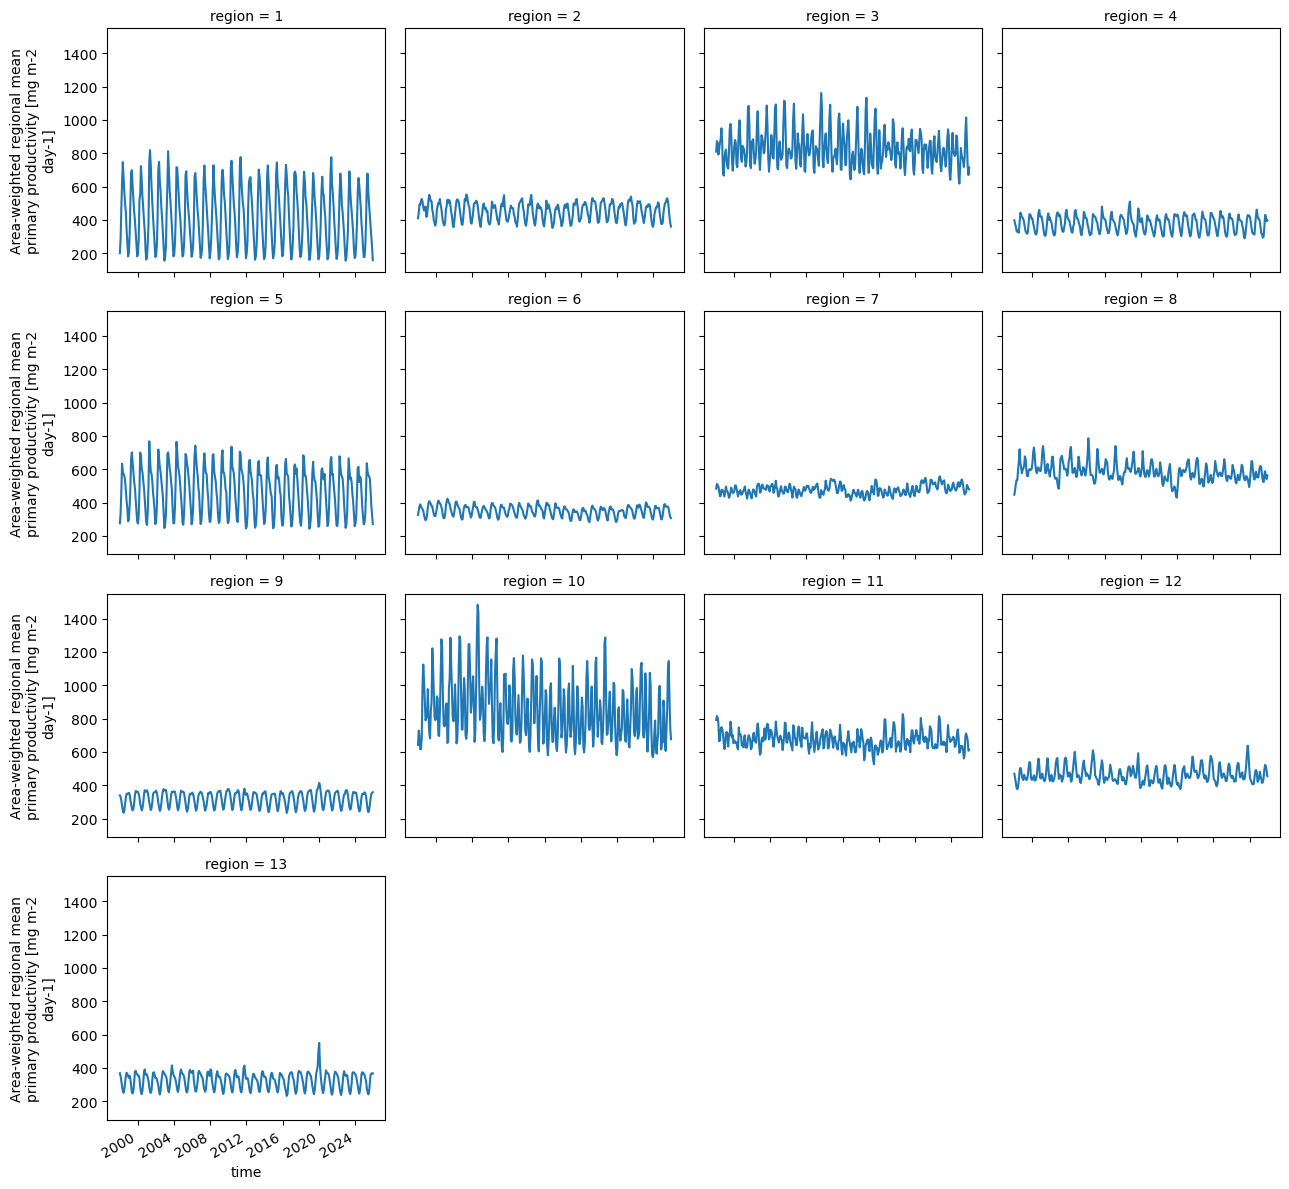

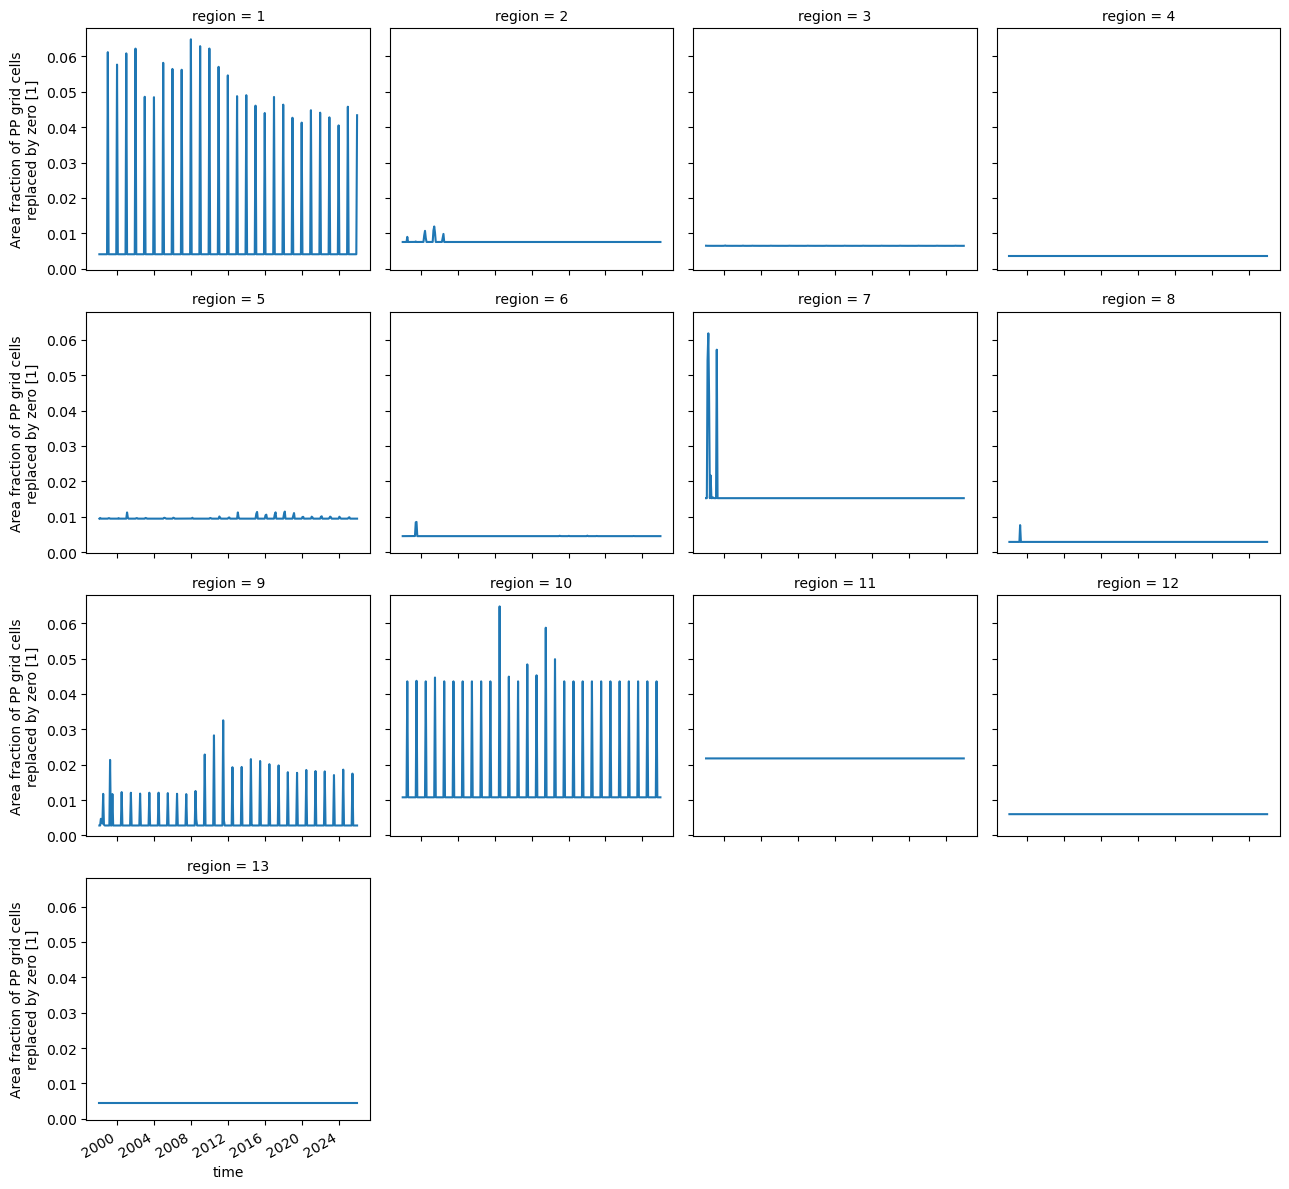

In [8]:
ds_pp_reg = xr.open_dataset(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/RECCAP2_region_mean_PP/GlobColour_PP_RECCAP2_13regions_area_mean_1998_2025.nc"
)

ds_pp_reg["PP"].plot.line(x="time", col="region", col_wrap=4)
plt.show()

ds_pp_reg["zero_filled_area_fraction"].plot.line(x="time", col="region", col_wrap=4)
plt.show()

<xarray.Dataset>
Dimensions:                    (time: 336, region: 13)
Coordinates:
  * time                       (time) datetime64[ns] 1998-01-15 ... 2025-12-15
  * region                     (region) int16 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    PP                         (time, region) float32 ...
    negative_grid_count        (time, region) int32 ...
    nan_grid_count             (time, region) int32 ...
    zero_filled_grid_count     (time, region) int32 ...
    negative_area_fraction     (time, region) float32 ...
    nan_area_fraction          (time, region) float32 ...
    zero_filled_area_fraction  (time, region) float32 ...
    region_name                (region) object ...
    basin                      (region) object ...
    original_region_id         (region) int16 ...
Attributes:
    title:                  GlobColour PP regional means over conservative RE...
    source_data_directory:  /nird/datalake/NS11071K/users/yongyub/Observation...
    source_file_pa

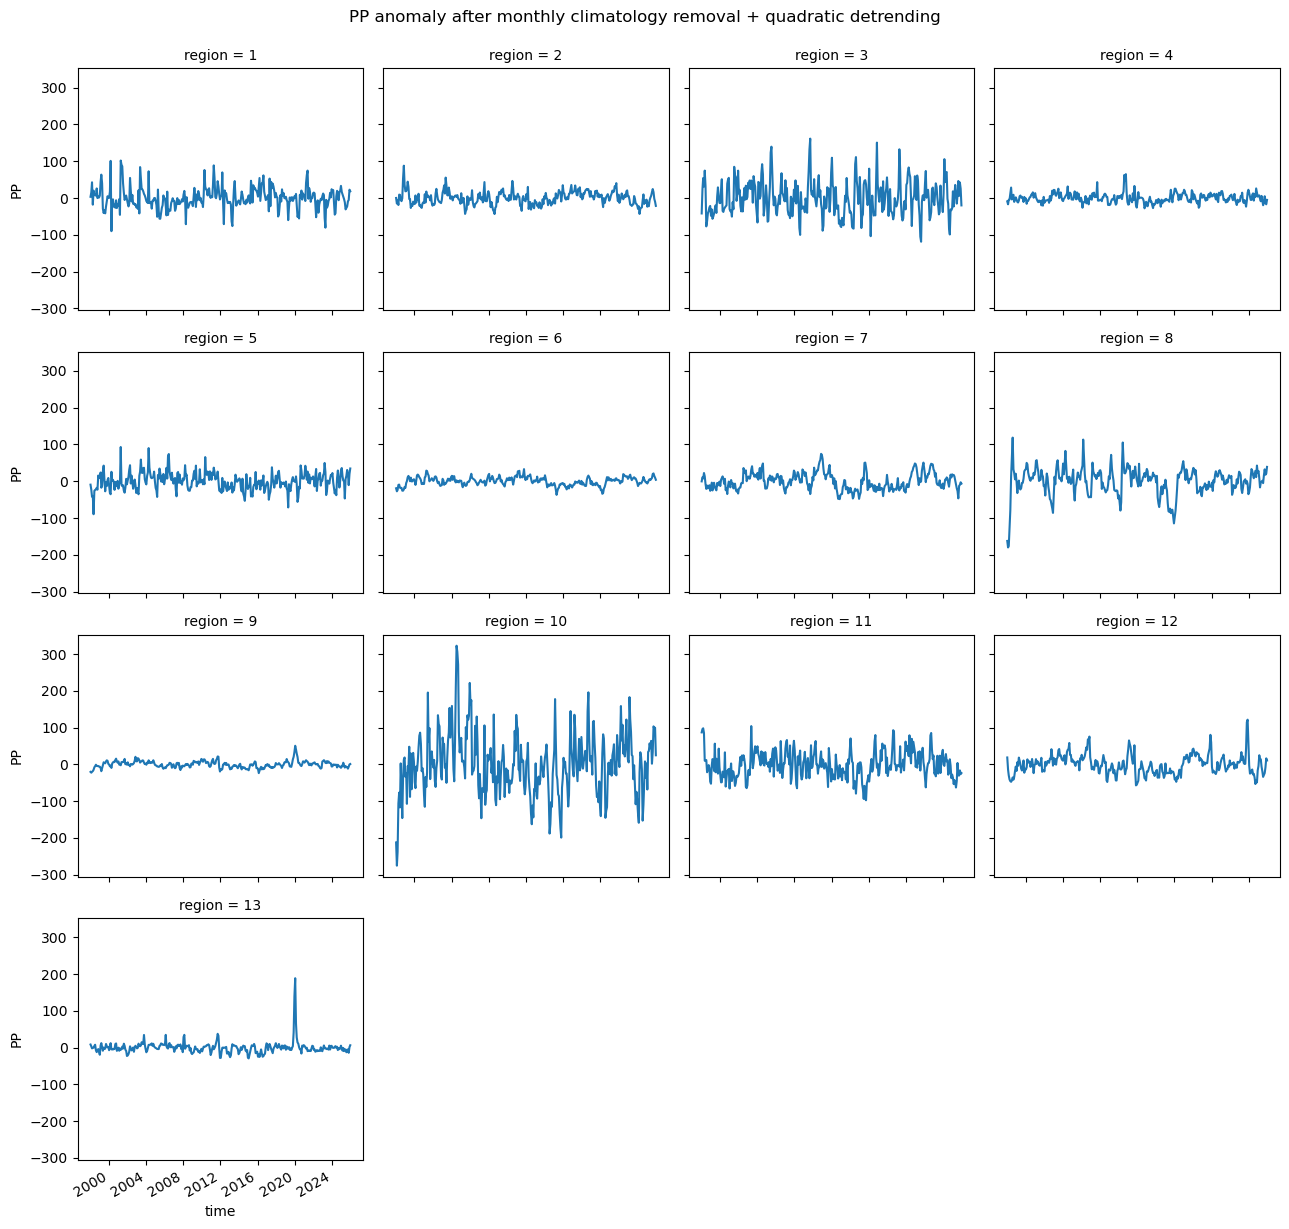

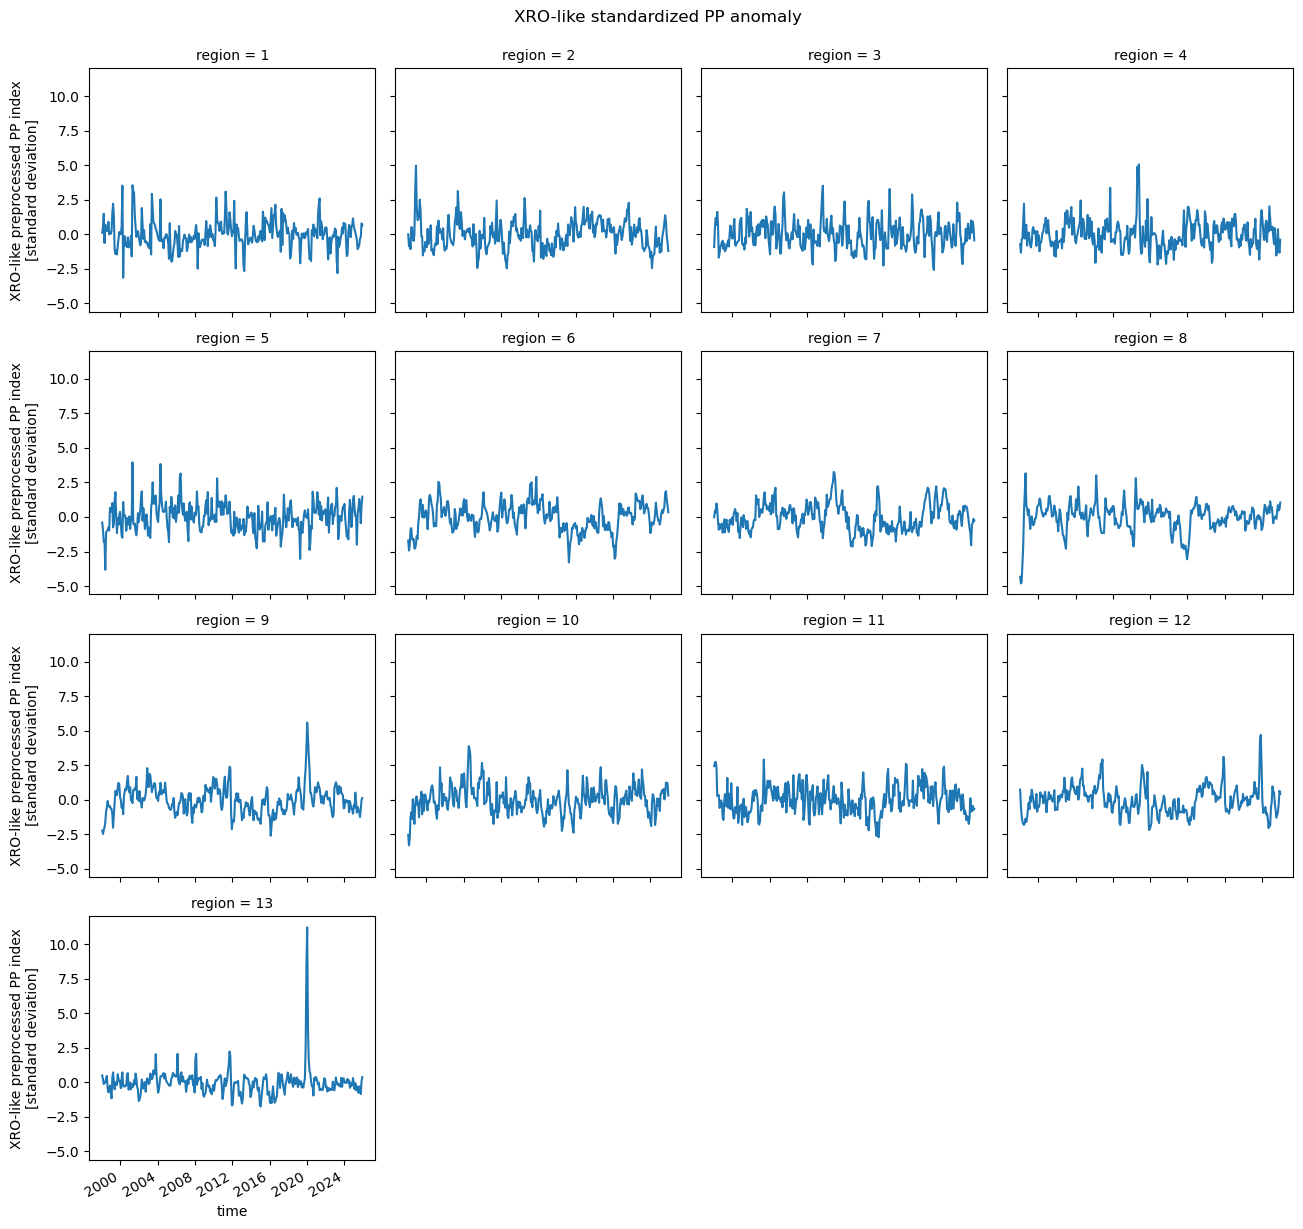

In [10]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Load regional PP
# ============================================================

FILE = (
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "RECCAP2_region_mean_PP/"
    "GlobColour_PP_RECCAP2_13regions_area_mean_1998_2025.nc"
)

ds_pp_reg = xr.open_dataset(FILE)

pp_raw = ds_pp_reg["PP"].sortby("time")

print(ds_pp_reg)
print(pp_raw)


# ============================================================
# Settings
# ============================================================

# For your current full observational PP period
CLIM_START = "1998-01-01"
CLIM_END   = "2025-12-31"

TREND_START = "1998-01-01"
TREND_END   = "2025-12-31"

# If this is later used in true prediction/reforecast,
# climatology/trend/std should be estimated from training period only.
STD_START = CLIM_START
STD_END   = CLIM_END


# ============================================================
# Helper functions
# ============================================================

def remove_monthly_climatology(x, clim_start=None, clim_end=None):
    """
    Remove monthly climatology for each region.

    x dims: time, region
    """
    if clim_start is not None or clim_end is not None:
        x_clim = x.sel(time=slice(clim_start, clim_end))
    else:
        x_clim = x

    clim = x_clim.groupby("time.month").mean("time", skipna=True)
    anom = x.groupby("time.month") - clim

    return anom, clim


def quadratic_detrend_xarray(x, trend_start=None, trend_end=None):
    """
    Remove quadratic trend from each region independently.

    x dims: time, region

    Fit:
        x(t) = a*t^2 + b*t + c

    where t is years since first selected trend time.
    """
    if trend_start is not None or trend_end is not None:
        x_fit = x.sel(time=slice(trend_start, trend_end))
    else:
        x_fit = x

    # Numeric time in years
    time_all = pd.to_datetime(x["time"].values)
    time_fit = pd.to_datetime(x_fit["time"].values)

    t0 = time_fit[0]
    t_all = ((time_all - t0) / np.timedelta64(1, "D")) / 365.25
    t_fit = ((time_fit - t0) / np.timedelta64(1, "D")) / 365.25

    out = xr.full_like(x, np.nan)

    for reg in x["region"].values:
        y_fit = x_fit.sel(region=reg).values.astype(float)

        ok = np.isfinite(y_fit)

        if ok.sum() < 6:
            continue

        coef = np.polyfit(t_fit[ok], y_fit[ok], deg=2)
        trend_all = np.polyval(coef, t_all)

        y_all = x.sel(region=reg).values.astype(float)
        out.loc[dict(region=reg)] = y_all - trend_all

    out.attrs = x.attrs.copy()
    out.attrs["detrending"] = "quadratic trend removed independently for each region"

    return out


def standardize_by_region(x, std_start=None, std_end=None):
    """
    Standardize each region:
        z = (x - mean) / std

    For anomaly input, mean is usually close to zero, but we still remove it.
    """
    if std_start is not None or std_end is not None:
        x_ref = x.sel(time=slice(std_start, std_end))
    else:
        x_ref = x

    mean = x_ref.mean("time", skipna=True)
    std = x_ref.std("time", skipna=True)

    z = (x - mean) / std

    z.attrs = x.attrs.copy()
    z.attrs["standardization"] = "region-wise mean removed and divided by region-wise standard deviation"

    return z, mean, std


# ============================================================
# XRO-like preprocessing
# ============================================================

# 1. Remove monthly climatology
pp_anom, pp_clim = remove_monthly_climatology(
    pp_raw,
    clim_start=CLIM_START,
    clim_end=CLIM_END,
)

# 2. Remove quadratic trend from anomaly
pp_anom_detrended = quadratic_detrend_xarray(
    pp_anom,
    trend_start=TREND_START,
    trend_end=TREND_END,
)

# 3. Standardize for plotting / XRO-like index comparison
pp_xro_like, pp_mean_ref, pp_std_ref = standardize_by_region(
    pp_anom_detrended,
    std_start=STD_START,
    std_end=STD_END,
)

pp_xro_like.name = "PP_xro_like"
pp_xro_like.attrs.update(
    {
        "long_name": "XRO-like preprocessed PP index",
        "description": (
            "Monthly climatology removed, quadratic trend removed, "
            "and standardized independently for each RECCAP2 region."
        ),
        "units": "standard deviation",
    }
)


# ============================================================
# Quick plots
# ============================================================

# Detrended anomaly
pp_anom_detrended.plot.line(x="time", col="region", col_wrap=4)
plt.suptitle("PP anomaly after monthly climatology removal + quadratic detrending", y=1.02)
plt.show()

# Standardized anomaly
pp_xro_like.plot.line(x="time", col="region", col_wrap=4)
plt.suptitle("XRO-like standardized PP anomaly", y=1.02)
plt.show()


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ============================================================
# Input
# ============================================================
# pp_xro_like: dims = time, region
# ds_pp_reg: region_name 포함한 dataset

x = pp_xro_like


# ============================================================
# Helper
# ============================================================

def get_region_label(ds, reg):
    try:
        name = str(ds["region_name"].sel(region=reg).values)
        return f"{int(reg)}. {name}"
    except Exception:
        return f"Region {int(reg)}"


def normality_summary(x, ds_pp_reg):
    rows = []

    for reg in x["region"].values:
        y = x.sel(region=reg).values.astype(float)
        y = y[np.isfinite(y)]

        if len(y) < 8:
            rows.append({
                "region": int(reg),
                "region_name": get_region_label(ds_pp_reg, reg),
                "n": len(y),
                "mean": np.nan,
                "std": np.nan,
                "skewness": np.nan,
                "excess_kurtosis": np.nan,
                "shapiro_p": np.nan,
                "jarque_bera_p": np.nan,
            })
            continue

        shapiro_stat, shapiro_p = stats.shapiro(y)
        jb_stat, jb_p = stats.jarque_bera(y)

        rows.append({
            "region": int(reg),
            "region_name": get_region_label(ds_pp_reg, reg),
            "n": len(y),
            "mean": np.mean(y),
            "std": np.std(y, ddof=1),
            "skewness": stats.skew(y, nan_policy="omit"),
            "excess_kurtosis": stats.kurtosis(y, fisher=True, nan_policy="omit"),
            "shapiro_p": shapiro_p,
            "jarque_bera_p": jb_p,
        })

    return pd.DataFrame(rows)


summary_df = normality_summary(x, ds_pp_reg)
summary_df

# Shapiro-Wilk p > 0.05  → Gaussian을 강하게 reject하지 못함
# Shapiro-Wilk p < 0.05  → Gaussian과 다르다고 볼 근거 있음
# skewness ≈ 0          → 좌우대칭
# excess kurtosis ≈ 0   → normal-like tail
# excess kurtosis > 0   → heavy tail
# excess kurtosis < 0   → light tail / flat distribution

,region,region_name,n,mean,std,skewness,excess_kurtosis,shapiro_p,jarque_bera_p
0,1,1. NA STSS,336,7.660544e-09,1.001492,0.445370,1.704610,2.447559e-07,5.681455e-12
1,2,2. NA STPS,336,-3.279032e-09,1.001491,0.544028,1.509793,3.000615e-04,2.959629e-11
2,3,3. AEQU,336,5.598330e-09,1.001491,0.446397,0.577255,2.928498e-03,3.662719e-04
3,4,4. SA STPS,336,2.679631e-09,1.001491,1.015060,3.328408,2.737802e-09,6.194706e-47
4,5,5. NP STSS,336,-1.078955e-08,1.001491,0.249493,1.557448,4.939008e-04,7.395361e-09
5,6,6. NP STPS,336,1.876504e-08,1.001491,-0.184784,0.295888,3.606935e-01,2.082724e-01
6,7,7. PEQU-W,336,3.964357e-09,1.001491,0.460344,-0.033288,4.797941e-04,2.628318e-03
7,8,8. PEQU-E,336,2.890149e-08,1.001491,-1.163483,4.184508,1.164352e-12,2.027521e-70
8,9,9. SP STPS,336,2.678800e-08,1.001491,0.934824,3.858806,6.490708e-09,1.275032e-56
9,10,10. Arabian Sea,336,-6.305137e-09,1.001491,0.329242,1.294449,8.371448e-04,3.871702e-07


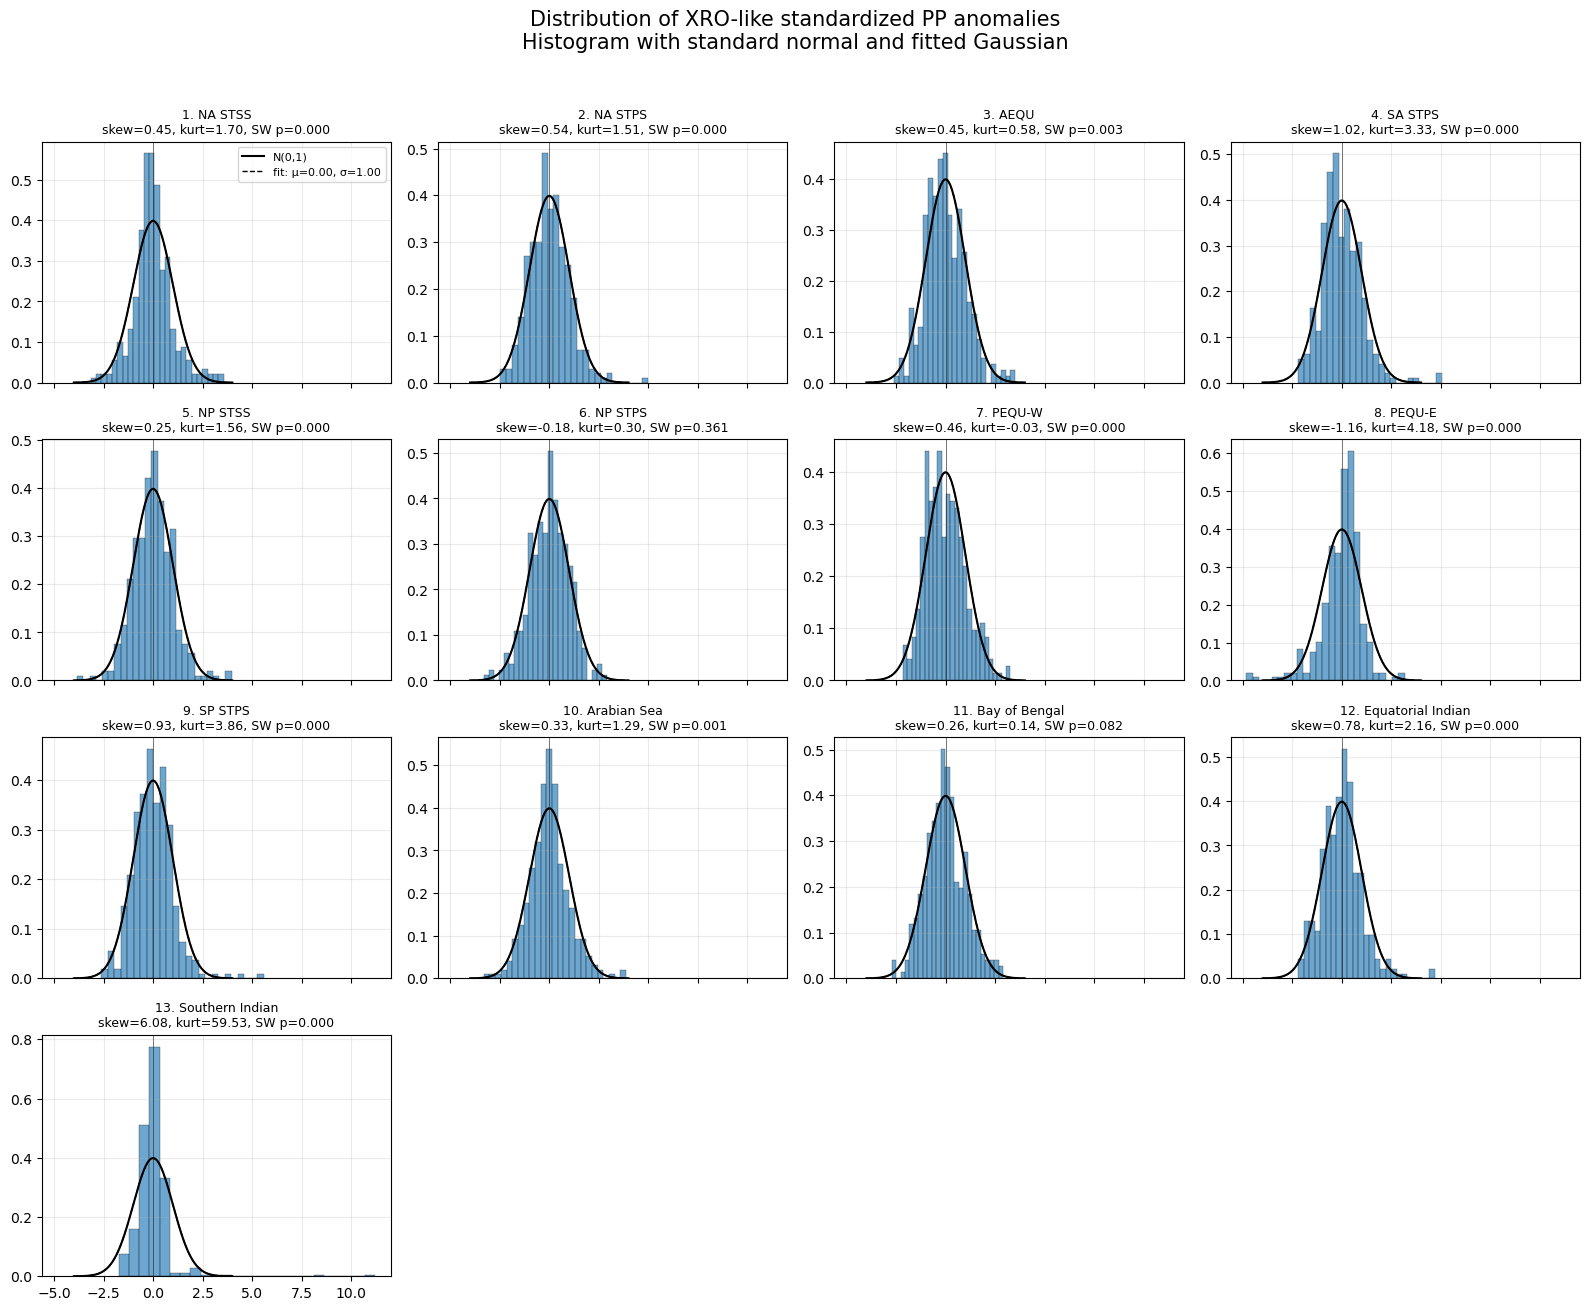

In [12]:
regions = x["region"].values
nreg = len(regions)

ncol = 4
nrow = int(np.ceil(nreg / ncol))

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(16, 3.2 * nrow),
    sharex=True,
    sharey=False
)

axes = axes.ravel()

xx = np.linspace(-4, 4, 300)
normal_pdf = stats.norm.pdf(xx, loc=0, scale=1)

for i, reg in enumerate(regions):
    ax = axes[i]

    y = x.sel(region=reg).values.astype(float)
    y = y[np.isfinite(y)]

    label = get_region_label(ds_pp_reg, reg)

    ax.hist(
        y,
        bins=25,
        density=True,
        alpha=0.65,
        edgecolor="k",
        linewidth=0.3
    )

    # Standard normal curve
    ax.plot(
        xx,
        normal_pdf,
        "k-",
        lw=1.5,
        label="N(0,1)"
    )

    # Also plot fitted Gaussian
    if len(y) > 3:
        mu = np.mean(y)
        sigma = np.std(y, ddof=1)

        if sigma > 0:
            fitted_pdf = stats.norm.pdf(xx, loc=mu, scale=sigma)
            ax.plot(
                xx,
                fitted_pdf,
                "k--",
                lw=1.0,
                label=f"fit: μ={mu:.2f}, σ={sigma:.2f}"
            )

    row = summary_df.loc[summary_df["region"] == int(reg)].iloc[0]

    ax.set_title(
        f"{label}\n"
        f"skew={row['skewness']:.2f}, kurt={row['excess_kurtosis']:.2f}, "
        f"SW p={row['shapiro_p']:.3f}",
        fontsize=9
    )

    ax.axvline(0, color="k", lw=0.7, alpha=0.5)
    ax.grid(alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8)

# Remove empty panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Distribution of XRO-like standardized PP anomalies\n"
    "Histogram with standard normal and fitted Gaussian",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

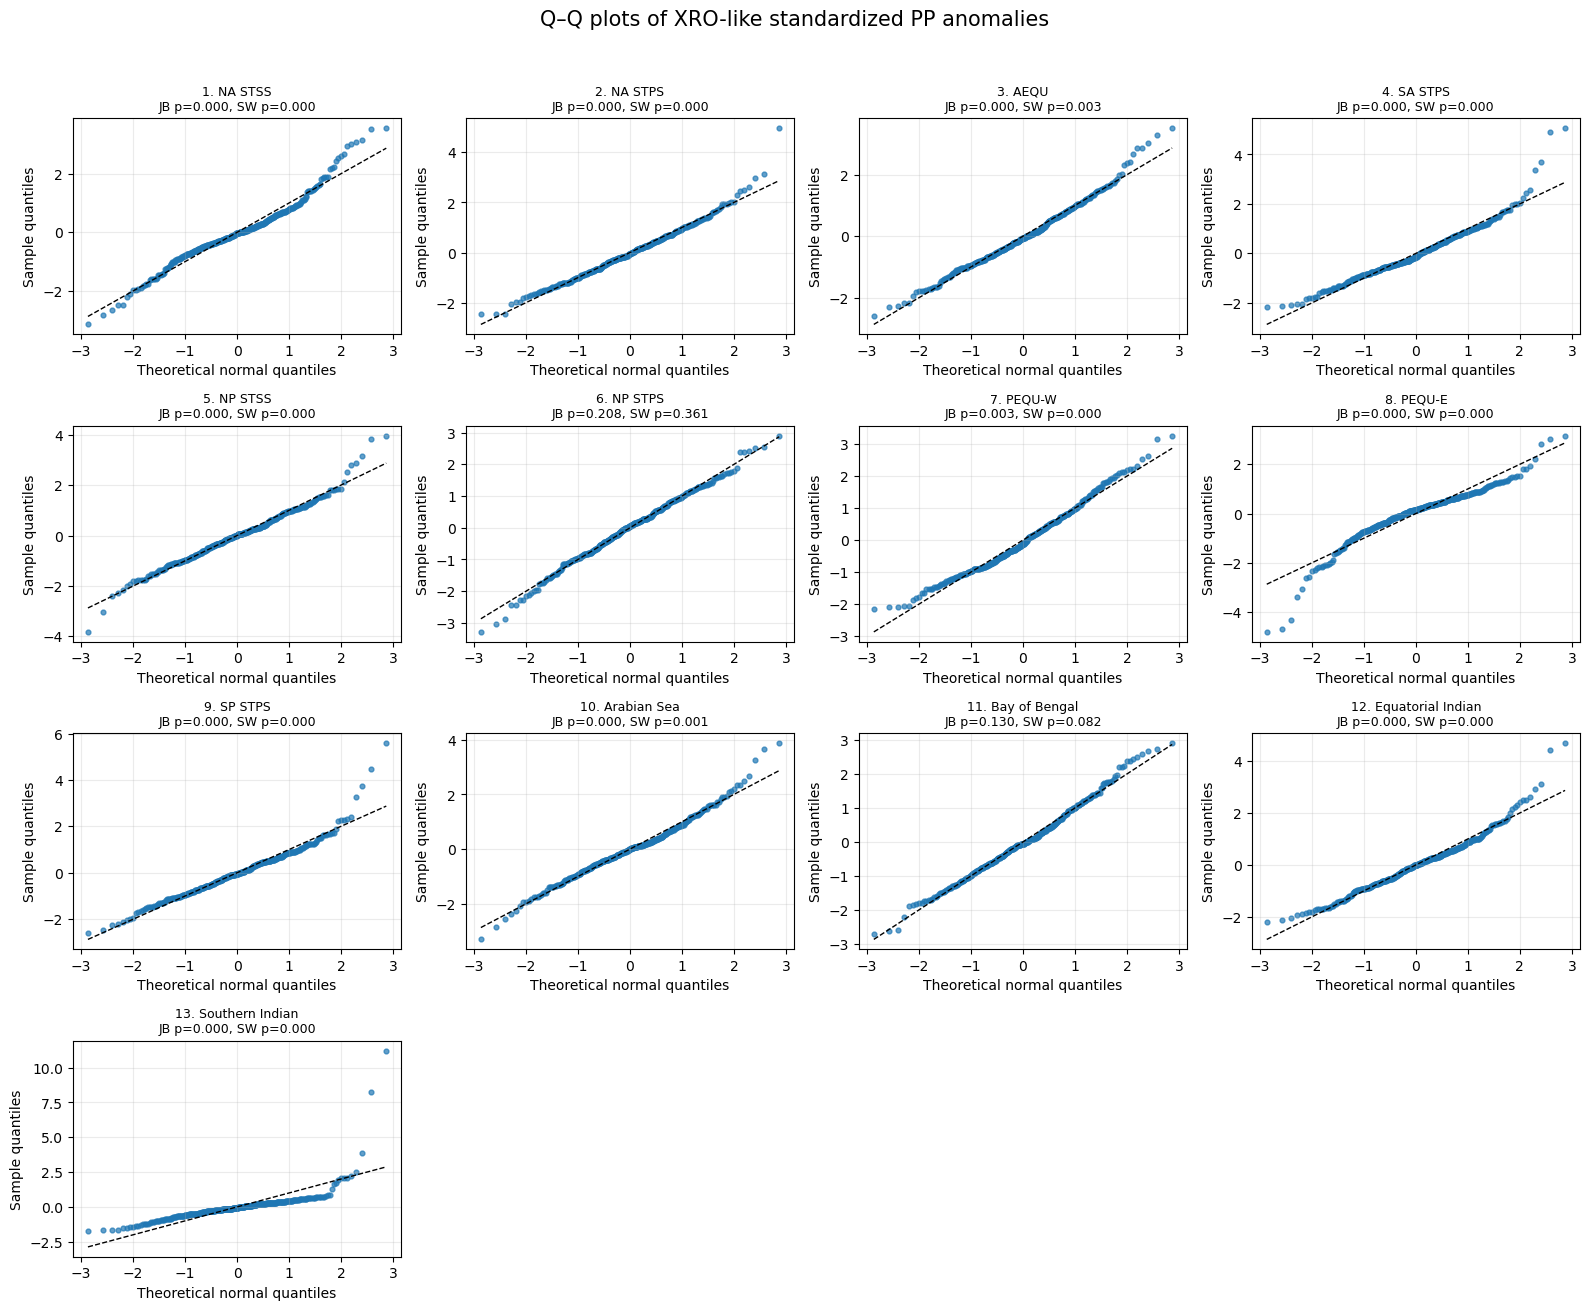

In [13]:
regions = x["region"].values
nreg = len(regions)

ncol = 4
nrow = int(np.ceil(nreg / ncol))

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(16, 3.2 * nrow)
)

axes = axes.ravel()

for i, reg in enumerate(regions):
    ax = axes[i]

    y = x.sel(region=reg).values.astype(float)
    y = y[np.isfinite(y)]

    label = get_region_label(ds_pp_reg, reg)

    if len(y) > 3:
        osm, osr = stats.probplot(y, dist="norm", fit=False)

        ax.scatter(osm, osr, s=12, alpha=0.7)

        # 1:1 reference line using sample mean/std
        mu = np.mean(y)
        sigma = np.std(y, ddof=1)
        qmin, qmax = np.nanmin(osm), np.nanmax(osm)

        qx = np.linspace(qmin, qmax, 100)
        ax.plot(qx, mu + sigma * qx, "k--", lw=1.0)

    row = summary_df.loc[summary_df["region"] == int(reg)].iloc[0]

    ax.set_title(
        f"{label}\n"
        f"JB p={row['jarque_bera_p']:.3f}, SW p={row['shapiro_p']:.3f}",
        fontsize=9
    )

    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Sample quantiles")
    ax.grid(alpha=0.25)

# Remove empty panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Q–Q plots of XRO-like standardized PP anomalies",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()